## Чтобы не перегружать репозиторий, я убрал csv версии файлов. Запустите два скрипта, которые переведут из parquet в csv

In [ ]:
import matplotlib.pyplot as plt
import subprocess, sys
from pathlib import Path
import pandas as pd
import json

In [1]:
# Run export scripts at notebook start (generates CSVs)
nb_root = Path('.')
scripts = [
    'scripts/export_news_collection.py',
    'scripts/export_news_collection_old.py',
]
for s in scripts:
    p = nb_root / s
    if p.exists():
        print(f'Running: {p}')
        res = subprocess.run([sys.executable, str(p)], capture_output=True, text=True)
    else:
        print(f'Script not found: {p}')

Running: scripts\export_news_collection.py
Running: scripts\export_news_collection_old.py


## Новости

### Описание полей для `news_collection_full.csv`
**Поля:**
- `title`: заголовок новости.
- `body`: полный текст новости.
- `date`: дата публикации в формате YYYY-MM-DD. Возможные значения: диапазон 2022-01-08…2024-12-15.
- `time`: время публикации (обычно HH:MM:SS).
- `tags`: список меток/тикеров (разделители `,` или `;`). Возможные значения: 3884 уникальных; примеры: ABIO, ABRD, AFKS, AFLT, AGRO, AKRN, ALRS, AMEZ, BELU, BSPB.
- `source`: источник. Возможные значения: bcs, bcs_tech, finam, rdv, smart_lab, t_analytic, t_invest.

In [22]:

pd.set_option('display.max_rows', None)

csv_path = Path('news_collection_full.csv')

news = pd.read_csv(csv_path, encoding='utf-8')

print('Loaded', news.shape[0], 'rows and', news.shape[1], 'columns')
#df[df["title"] != "no title"].head(10)
news.head(10)

Loaded 91955 rows and 6 columns


,title,body,date,time,tags,source
0,no title,"""После падения добычи в 2022-2023 годах Газпро...",2024-09-09,16:16:54,['цифры'],rdv
1,no title,""" Рейтинг акций комьюнити РДВ. #опрос """,2024-09-09,15:38:21,['опрос'],rdv
2,no title,"""Нефть Brent упала до $71, Urals - до $60 за б...",2024-09-09,14:40:17,['шокновости'],rdv
3,no title,"""️ Ставка ЦБ вряд ли уйдёт выше 18%. ЦБ переже...",2024-09-09,12:54:10,['VIPtalk'],rdv
4,no title,"""Эксперты клуба RDV PREMIUM 361° дали коммента...",2024-09-09,10:25:07,[],rdv
5,no title,"""Эксперты клуба RDV PREMIUM 361° дали коммента...",2024-09-09,10:25:06,[],rdv
6,no title,"""Выручка девелоперов в Московском регионе (Мос...",2024-09-09,09:11:47,['аналитика'],rdv
7,no title,"""Рейтинг акций коммьюнити РДВ. #опрос Какой ак...",2024-09-09,08:56:44,['опрос'],rdv
8,no title,""" Рейтинг дивдоходностей за 2024 год. Прогноз ...",2024-09-09,07:51:20,['цифры'],rdv
9,no title,"""Главное к открытию понедельника (09.09): #бри...",2024-09-09,06:26:47,['брифинг'],rdv


## Новости с 08.01.2022 по 16.12.2024

### Описание полей для анализа дат
**Поля:**
- `date`: дата публикации в формате YYYY-MM-DD. Возможные значения: диапазон 2022-01-08…2024-12-15.

In [3]:
dates = pd.to_datetime(news['date'], errors='coerce')
print('Date range:', dates.min(), 'to', dates.max())

Date range: 2022-01-08 00:00:00 to 2024-12-15 00:00:00


In [4]:
for i in news['tags'].unique()[:10]:
    print(i)

['цифры']
['опрос']
['шокновости']
['VIPtalk']
[]
['аналитика']
['брифинг']
['weekly']
['FLOT', 'Дивиденды']
['сборник']


Это датасет тех же самых новостей, но индексация такая же как и в размеченных по настроению датасетах.
#### Тут отсутствуют теги.    
Внутри директории файл "news_collection_old.parquet" - в котором индексация новостных статей соответствует индексации в разметке. Разметка от моделей GPT4o (~ 15,000), LLama3:8b (~23,000)

In [5]:
csv_path = Path('news_collection_old.csv')

news_old = pd.read_csv(csv_path, encoding='utf-8')

print('Loaded', news_old.shape[0], 'rows and', news_old.shape[1], 'columns')
news_old.head(10)

Loaded 79705 rows and 6 columns


,title,body,date,time,tags,source
0,no title,"""После падения добычи в 2022-2023 годах Газпро...",2024-09-09,16:16:54,NaN,rdv
1,no title,""" Рейтинг акций комьюнити РДВ. #опрос """,2024-09-09,15:38:21,NaN,rdv
2,no title,"""Нефть Brent упала до $71, Urals - до $60 за б...",2024-09-09,14:40:17,NaN,rdv
3,no title,"""️ Ставка ЦБ вряд ли уйдёт выше 18%. ЦБ переже...",2024-09-09,12:54:10,NaN,rdv
4,no title,"""Эксперты клуба RDV PREMIUM 361° дали коммента...",2024-09-09,10:25:07,NaN,rdv
5,no title,"""""",2024-09-09,10:25:06,NaN,rdv
6,no title,"""Эксперты клуба RDV PREMIUM 361° дали коммента...",2024-09-09,10:25:06,NaN,rdv
7,no title,"""Выручка девелоперов в Московском регионе (Мос...",2024-09-09,09:11:47,NaN,rdv
8,no title,"""Рейтинг акций коммьюнити РДВ. #опрос Какой ак...",2024-09-09,08:56:44,NaN,rdv
9,no title,""" Рейтинг дивдоходностей за 2024 год. Прогноз ...",2024-09-09,07:51:20,NaN,rdv


In [13]:
len(news_old["source"].value_counts())
news_old.iloc[583]

title                                              no title
body      " Банк Санкт-Петербург (BSPB): +36% потенциала...
date                                             2024-06-13
time                                               13:02:29
tags                                                    NaN
source                                                  rdv
Name: 583, dtype: object

## Описание новостей от ChatGPT4o

### Описание полей для `news_descriptions_GPT4o.json`
#### 15000 записей
**Поля:**
- `thinking`: пояснение/черновик модели (текст).
- `article_type`: тип статьи. Возможные значения: advertising, finance, opinions, others, politics, technical analysis.
- `country`: география. 191 уникальное значение; примеры: RU, Russia, US, USA, EU, Global, China, Germany, UK, United States.
- `sectors`: отрасли (36). Возможные значения: Aerospace, Automotive, Basic Materials, Communication Services, Communications, Communications Services, Consumer Cyclical, Consumer Defensive, Consumer Discretionary, Consumer Services, Currency, Defense, Education, Education Services, Energy, Engineering, Finance, Financial Service, Financial Services, Healthcare, Industrial, Industrials, Information Technology, Insurance, International Relations, Materials, Others, Real Estate, Retail, Technology, Telecommunication, Telecommunication Services, Transport, Transportation, Utilities, no sectors.
- `tickers`: тикеры/символы (1682 уникальных). Примеры: AAPL, ABIO, ABRD, ACRN, 1810.HK, #PLZL, #POLY, $GZPR, $SMLT, $SOFL.
- `sentiment_score`: числовой скор тональности (не дискретный).

In [7]:
description_GPT4o_path = Path("news_descriptions\\news_descriptions_GPT4o.json")
GPT4o_description_df = pd.read_json(description_GPT4o_path).transpose()
print(GPT4o_description_df.shape)
GPT4o_description_df.head(20)

(15000, 6)


,thinking,article_type,country,sectors,tickers,sentiment_score
0,The article discusses Gazprom's production fig...,finance,[Russia],[Energy],[GAZP],-0.5
1,The article title suggests it is about a commu...,advertising,[],[],[],0.0
2,The article discusses the decline in oil price...,finance,"[Russia, United States]","[Energy, Financial Service]",[],-0.5
3,The article discusses economic forecasts and f...,opinions,[Russia],"[Financial Service, Real Estate]",[MOEX],0.0
4,The article is a commentary by RDV PREMIUM 361...,advertising,[Russia],[Real Estate],"[SMLT, ETLN, LSRG, PIKK]",0.5
5,"The article is empty, which means there is no ...",others,[],[],[],0.0
6,The article discusses expert opinions from the...,advertising,[Russia],"[Real Estate, Basic Materials]","[DOMKLI, METAL]",-0.3
7,The article highlights revenue figures for rea...,finance,[Russia],"[Real Estate, Basic Materials, Industrials]","[PIKK, LSRG, MSTT]",-0.5
8,The article is focused on the RDV community po...,advertising,[Russia],[],[],0.2
9,The article focuses on the forecasted dividend...,finance,[Russia],"[Energy, Financial Service, Communication Serv...","[MTSS, BSPB, LKOH, TATN, SNGSP]",1.0


In [17]:
GPT4o_description_df.iloc[583].thinking

title                                              no title
body      "Главное к открытию среды (05.06): #брифинг  З...
date                                             2024-06-05
time                                               06:30:23
tags                                            ['брифинг']
source                                                  rdv
Name: 583, dtype: object

## Описание новостей от LLama3

### Описание полей для `news_description_LLama3_8b.json`
#### 25728 записей
**Поля:**
- `thinking`: пояснение/черновик модели (текст).
- `article_type`: тип статьи. Возможные значения: advertising, finance, opinions, others, politics, technical analysis.
- `country`: география. 199 уникальных значений; примеры: Russia, US, EU, China, Kazakhstan, Turkey, Japan, India, UAE, UK.
- `sectors`: отрасли (308 уникальных). Примеры: Aerospace, Agriculture, Automotive, Energy, Industrials, Finance, Technology, Retail, Real Estate, Utilities.
- `tickers`: тикеры/символы (3301 уникальный).
- `sentiment_score`: числовой скор тональности.

In [8]:
description_LLama3_8b_path = Path("news_descriptions\\news_description_LLama3_8b.json")
LLama3_8b_description_df = pd.read_json(description_LLama3_8b_path).transpose()

# расплющиваем description
normalize_LLama3_8b_description = pd.json_normalize(LLama3_8b_description_df["description"])

# объединяем с исходным df
LLama3_8b_description_df = pd.concat([LLama3_8b_description_df.drop(columns=["description"]), normalize_LLama3_8b_description], axis=1)

print(LLama3_8b_description_df.shape)
LLama3_8b_description_df.head(10)

(25728, 6)


,thinking,article_type,country,sectors,tickers,sentiment_score
0,The article discusses the recent trend in Gazp...,finance,[Russia],[Energy],[GAZP],-0.5
1,The article appears to be about the community ...,opinions,[Russia],[],[],0.0
2,The article discusses a significant decline in...,finance,"[Russia, USA]",[Energy],[$SBER],-1.0
3,The article discusses the potential future of ...,finance,[Russia],[Financial Service],[],0.0
4,"Based on the article, it's clear that it falls...",finance,[Russia],"[Real Estate, Financial Service]","[SBER (Sberbank, not directly relevant but a m...",0.5
5,The article discusses the impact of a new gove...,finance,[Russia],"[Consumer Cyclical, Energy]","[MTSS, RTKS]",0.5
6,"Based on the article content, it can be inferr...",finance,[Russia],"[Consumer Cyclical, Real Estate]",[],-1.0
7,The article discusses the revenue of developer...,finance,[Russia],"[Construction, Materials]","[MTSS, TATN]",-0.5
8,The article appears to be an opinion-based pie...,finance,[others],[],[],0.0
9,The article is about a dividend yield ranking ...,finance,[Russia],"[Telecommunications Services, Financial Services]","[MTSS, BSPB, LKOH, TATN, SBER]",0.5


## Тикеры

### Описание полей для `tickers_description.json`
**Поля:**
- `ticker`: тикер (238 уникальных).
- `description`: текстовое описание компании.

In [ ]:
# Load `tickers_description.json` into a pandas DataFrame
p_candidate = Path('tickers_description.json')
with p_candidate.open(encoding='utf-8') as f:
    tickers = json.load(f)
df_tickers = pd.DataFrame.from_dict(tickers, orient='index').reset_index().rename(columns={'index':'ticker'})
print('Loaded', df_tickers.shape[0], 'tickers and', df_tickers.shape[1], 'columns')
df_tickers

Loaded 238 tickers and 2 columns


,ticker,0
0,ABIO,Артген биотех (ранее Институт Стволовых Клеток...
1,ABRD,Завод шампанских вин «Абрау-Дюрсо» — крупнейши...
2,AFKS,АФК «Система» является одной из самых крупных ...
3,AFLT,ПАО «Аэрофлот» — крупнейший авиаперевозчик Рос...
4,AKRN,ПАО «Акрон» — один из ведущих вертикально инте...
5,ALRS,ПАО «АЛРОСА» — лидер алмазодобывающей отрасли ...
6,APRI,Специализируясь на реализации проектов строите...
7,APTK,"ПАО «Аптечная сеть 36,6» — крупная российская ..."
8,AQUA,ПАО «ИНАРКТИКА» (ранее Русская Аквакультура) я...
9,ARSA,ПАО «Управляющая компания «Арсагера» — первая ...


### Описание полей для `candles_data/1d/*.csv`
**Поля:**
- Индекс `begin`: дата/время свечи (используется как индекс при чтении).
- Остальные столбцы — тикеры (253 уникальных).
- Значения: цены/объёмы для соответствующего типа файла (`open`, `high`, `low`, `close`, `value`).

In [10]:
base = Path("candles_data\\1d")
for name in ['open','high','low','close','value']:
    p = base / f'{name}.csv'
    candles = pd.read_csv(p, index_col=0, parse_dates=True)
    display(candles.head())          # в Jupyter покажет первые строки
    print("path: ", p)
    print(name, 'shape=', candles.shape)
    print(candles.index.min(), candles.index.max(), 'freq=', pd.infer_freq(candles.index))
    print('missing per column:\\n', candles.isna().sum().sort_values(ascending=False).head())
    print('\n\n\n\n')

,ABIO,ABRD,ACKO,AFKS,AFLT,AGRO,AKRN,ALRS,AMEZ,APRI,...,WUSH,YAKG,YDEX,YKEN,YKENP,YRSB,YRSBP,ZAYM,ZILL,ZVEZ
begin,,,,,,,,,,,,,,,,,,,,,
2022-07-01,57.78,170.5,NaN,14.310,26.60,859.6,18182,67.49,19.855,NaN,...,NaN,110.00,NaN,0.2775,0.2700,172.0,83.0,NaN,2940,3.545
2022-07-04,56.30,172.5,NaN,15.000,26.80,888.8,18770,66.18,21.680,NaN,...,NaN,110.30,NaN,0.2835,0.2700,172.0,83.0,NaN,2965,3.515
2022-07-05,57.00,173.0,NaN,15.100,27.00,854.4,18368,64.00,21.960,NaN,...,NaN,110.00,NaN,0.2770,0.2685,172.0,83.0,NaN,3010,3.475
2022-07-06,56.80,173.0,NaN,14.950,28.16,824.0,17830,64.97,21.490,NaN,...,NaN,109.45,NaN,0.2745,0.2740,NaN,82.5,NaN,2955,3.430
2022-07-07,61.04,171.0,NaN,15.165,27.48,843.6,18000,64.99,21.315,NaN,...,NaN,107.05,NaN,0.2695,0.2560,170.0,83.0,NaN,2925,3.510


,ABIO,ABRD,ACKO,AFKS,AFLT,AGRO,AKRN,ALRS,AMEZ,APRI,...,WUSH,YAKG,YDEX,YKEN,YKENP,YRSB,YRSBP,ZAYM,ZILL,ZVEZ
begin,,,,,,,,,,,,,,,,,,,,,
2022-07-01,57.78,170.5,NaN,14.310,26.60,859.6,18182,67.49,19.855,NaN,...,NaN,110.00,NaN,0.2775,0.2700,172.0,83.0,NaN,2940,3.545
2022-07-04,56.30,172.5,NaN,15.000,26.80,888.8,18770,66.18,21.680,NaN,...,NaN,110.30,NaN,0.2835,0.2700,172.0,83.0,NaN,2965,3.515
2022-07-05,57.00,173.0,NaN,15.100,27.00,854.4,18368,64.00,21.960,NaN,...,NaN,110.00,NaN,0.2770,0.2685,172.0,83.0,NaN,3010,3.475
2022-07-06,56.80,173.0,NaN,14.950,28.16,824.0,17830,64.97,21.490,NaN,...,NaN,109.45,NaN,0.2745,0.2740,NaN,82.5,NaN,2955,3.430
2022-07-07,61.04,171.0,NaN,15.165,27.48,843.6,18000,64.99,21.315,NaN,...,NaN,107.05,NaN,0.2695,0.2560,170.0,83.0,NaN,2925,3.510


path:  candles_data\1d\open.csv
open shape= (553, 252)
2022-07-01 00:00:00 2024-08-30 00:00:00 freq= None
missing per column:\n ACKO    553
HEAD    553
GAZC    551
GAZS    551
GAZT    551
dtype: int64







,ABIO,ABRD,ACKO,AFKS,AFLT,AGRO,AKRN,ALRS,AMEZ,APRI,...,WUSH,YAKG,YDEX,YKEN,YKENP,YRSB,YRSBP,ZAYM,ZILL,ZVEZ
begin,,,,,,,,,,,,,,,,,,,,,
2022-07-01,57.80,173.5,NaN,15.400,27.60,880.0,18780,67.49,22.720,NaN,...,NaN,110.00,NaN,0.2865,0.2785,172.0,83.0,NaN,3025,3.560
2022-07-04,59.00,174.5,NaN,15.490,27.30,888.8,18800,66.50,23.400,NaN,...,NaN,110.30,NaN,0.2900,0.2785,174.0,83.0,NaN,3095,3.590
2022-07-05,57.40,174.0,NaN,15.184,28.48,862.8,18520,65.20,22.500,NaN,...,NaN,110.00,NaN,0.2840,0.2700,172.0,83.0,NaN,3010,3.475
2022-07-06,62.38,174.5,NaN,15.228,28.48,855.0,18350,66.30,21.915,NaN,...,NaN,110.00,NaN,0.2750,0.2740,NaN,83.0,NaN,3005,3.570
2022-07-07,63.24,178.5,NaN,15.300,28.08,865.0,18582,65.84,21.850,NaN,...,NaN,110.85,NaN,0.2700,0.2650,172.0,83.5,NaN,2995,3.640


,ABIO,ABRD,ACKO,AFKS,AFLT,AGRO,AKRN,ALRS,AMEZ,APRI,...,WUSH,YAKG,YDEX,YKEN,YKENP,YRSB,YRSBP,ZAYM,ZILL,ZVEZ
begin,,,,,,,,,,,,,,,,,,,,,
2022-07-01,57.78,170.5,NaN,14.310,26.60,859.6,18182,67.49,19.855,NaN,...,NaN,110.00,NaN,0.2775,0.2700,172.0,83.0,NaN,2940,3.545
2022-07-04,56.30,172.5,NaN,15.000,26.80,888.8,18770,66.18,21.680,NaN,...,NaN,110.30,NaN,0.2835,0.2700,172.0,83.0,NaN,2965,3.515
2022-07-05,57.00,173.0,NaN,15.100,27.00,854.4,18368,64.00,21.960,NaN,...,NaN,110.00,NaN,0.2770,0.2685,172.0,83.0,NaN,3010,3.475
2022-07-06,56.80,173.0,NaN,14.950,28.16,824.0,17830,64.97,21.490,NaN,...,NaN,109.45,NaN,0.2745,0.2740,NaN,82.5,NaN,2955,3.430
2022-07-07,61.04,171.0,NaN,15.165,27.48,843.6,18000,64.99,21.315,NaN,...,NaN,107.05,NaN,0.2695,0.2560,170.0,83.0,NaN,2925,3.510


...

path:  candles_data\1d\low.csv
low shape= (553, 252)
2022-07-01 00:00:00 2024-08-30 00:00:00 freq= None
missing per column:\n ACKO    553
HEAD    553
GAZC    551
GAZS    551
GAZT    551
dtype: int64







,ABIO,ABRD,ACKO,AFKS,AFLT,AGRO,AKRN,ALRS,AMEZ,APRI,...,WUSH,YAKG,YDEX,YKEN,YKENP,YRSB,YRSBP,ZAYM,ZILL,ZVEZ
begin,,,,,,,,,,,,,,,,,,,,,
2022-07-01,56.28,171.5,NaN,14.850,26.74,872.0,18660,66.24,21.220,NaN,...,NaN,107.00,NaN,0.282,0.2785,170.0,82.5,NaN,2920,3.500
2022-07-04,56.90,173.0,NaN,15.000,27.12,854.4,18422,64.55,21.895,NaN,...,NaN,109.50,NaN,0.283,0.2785,172.0,83.0,NaN,3010,3.480
2022-07-05,56.38,172.5,NaN,15.000,28.26,837.2,17902,64.99,21.500,NaN,...,NaN,109.20,NaN,0.273,0.2680,170.0,82.5,NaN,2950,3.470
2022-07-06,60.68,172.0,NaN,15.163,27.34,843.8,18088,64.96,21.325,NaN,...,NaN,107.70,NaN,0.273,0.2580,NaN,82.5,NaN,2985,3.550
2022-07-07,58.70,172.5,NaN,15.051,27.78,860.0,18402,65.35,21.375,NaN,...,NaN,110.45,NaN,0.269,0.2650,172.0,83.0,NaN,2900,3.605


path:  candles_data\1d\close.csv
close shape= (553, 252)
2022-07-01 00:00:00 2024-08-30 00:00:00 freq= None
missing per column:\n ACKO    553
HEAD    553
GAZC    551
GAZS    551
GAZT    551
dtype: int64







,ABIO,ABRD,ACKO,AFKS,AFLT,AGRO,AKRN,ALRS,AMEZ,APRI,...,WUSH,YAKG,YDEX,YKEN,YKENP,YRSB,YRSBP,ZAYM,ZILL,ZVEZ
begin,,,,,,,,,,,,,,,,,,,,,
2022-07-01,9061161.0,3371415,NaN,800070134.3,135396783.4,43947286.4,102197744,841793004.8,63526780.0,NaN,...,NaN,4842215.5,NaN,58550.0,13650.0,10240.0,30435.0,NaN,1472265,171825
2022-07-04,11274502.2,3139485,NaN,504082601.1,109467642.6,47796858.4,101970336,573081202.9,83929642.5,NaN,...,NaN,2129976.0,NaN,79785.0,38505.0,18960.0,11595.0,NaN,1912220,714080
2022-07-05,7487469.0,2981070,NaN,250439785.4,181704169.8,63770578.8,195810230,695797460.8,8803550.5,NaN,...,NaN,1219360.0,NaN,139495.0,74310.0,15320.0,4145.0,NaN,658095,106685
2022-07-06,55416892.8,5011205,NaN,371256364.6,218575765.2,45364247.6,87735742,563219863.8,4254449.0,NaN,...,NaN,1481268.5,NaN,76860.0,53265.0,NaN,4970.0,NaN,1519170,214195
2022-07-07,24377859.4,5390310,NaN,375531923.6,227550993.4,26555784.2,90460100,280164315.8,4110041.5,NaN,...,NaN,3706630.0,NaN,37725.0,28765.0,3420.0,12450.0,NaN,2837500,186955


path:  candles_data\1d\value.csv
value shape= (553, 252)
2022-07-01 00:00:00 2024-08-30 00:00:00 freq= None
missing per column:\n ACKO    553
HEAD    553
GAZC    551
GAZS    551
GAZT    551
dtype: int64







In [18]:
# Склейка свечей в длинный формат: дата, тикер, open/high/low/close/value
base = Path("candles_data\\1d")
files = ['open','high','low','close','value']

long_parts = []
for name in files:
    p = base / f"{name}.csv"
    df_wide = pd.read_csv(p, parse_dates=['begin'])
    df_long = df_wide.melt(id_vars=['begin'], var_name='ticker', value_name=name)
    long_parts.append(df_long)

# объединяем по (begin, ticker)
candles_long = long_parts[0]
for part in long_parts[1:]:
    candles_long = candles_long.merge(part, on=['begin', 'ticker'], how='outer')

candles_long = candles_long.rename(columns={'begin': 'date'})
print('candles_long shape:', candles_long.shape)
display(candles_long.head(10))

candles_long shape: (139356, 7)


,date,ticker,open,high,low,close,value
0,2022-07-01,ABIO,57.780,57.80,55.86,56.28,9061161.0
1,2022-07-01,ABRD,170.500,173.50,169.50,171.50,3371415.0
2,2022-07-01,ACKO,NaN,NaN,NaN,NaN,NaN
3,2022-07-01,AFKS,14.310,15.40,14.20,14.85,800070134.3
4,2022-07-01,AFLT,26.600,27.60,26.02,26.74,135396783.4
5,2022-07-01,AGRO,859.600,880.00,846.00,872.00,43947286.4
6,2022-07-01,AKRN,18182.000,18780.00,18000.00,18660.00,102197744.0
7,2022-07-01,ALRS,67.490,67.49,65.90,66.24,841793004.8
8,2022-07-01,AMEZ,19.855,22.72,19.62,21.22,63526780.0
9,2022-07-01,APRI,NaN,NaN,NaN,NaN,NaN


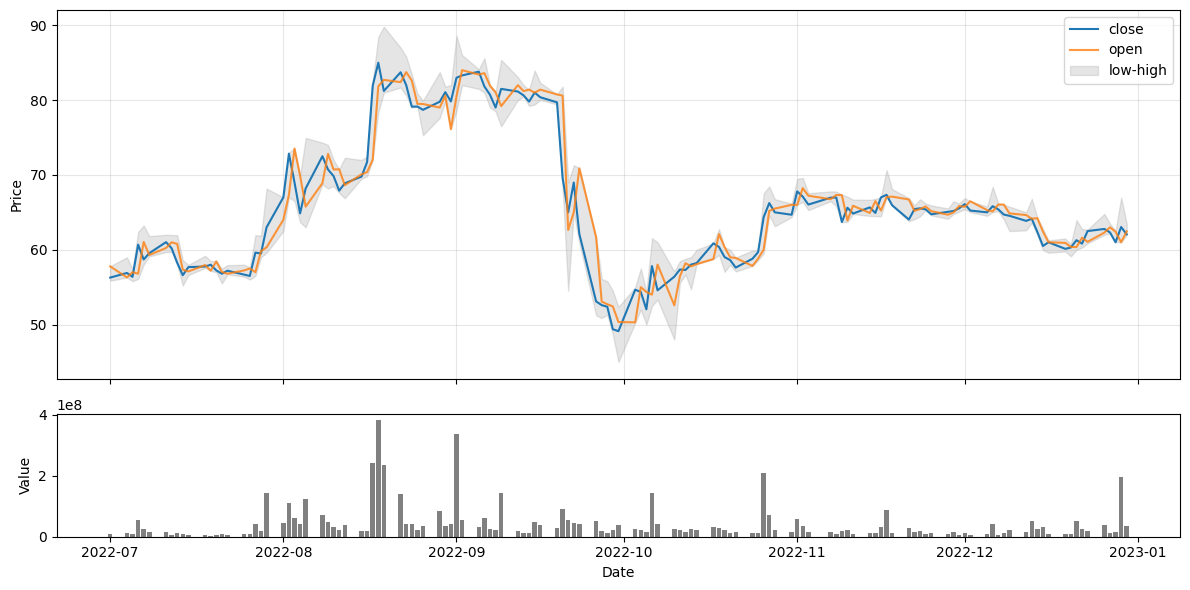

In [20]:
# Plotting helper for `candles_long` dataframe
def plot_ticker(df, ticker, start=None, end=None, figsize=(12,6)):
    """Plot price (open/close/range) and `value` for a single `ticker`.
    df: DataFrame with columns ['date','ticker','open','high','low','close','value']
    start/end: optional date strings (inclusive).
    """
    df2 = df.copy()
    df2['date'] = pd.to_datetime(df2['date'])
    mask = df2['ticker'] == ticker
    if start is not None:
        mask &= df2['date'] >= pd.to_datetime(start)
    if end is not None:
        mask &= df2['date'] <= pd.to_datetime(end)
    sub = df2.loc[mask].sort_values('date')
    if sub.empty:
        print('No data for', ticker)
        return
    fig, axes = plt.subplots(2,1, sharex=True, figsize=figsize, gridspec_kw={'height_ratios':[3,1]})
    ax = axes[0]
    ax.plot(sub['date'], sub['close'], label='close', color='tab:blue')
    ax.plot(sub['date'], sub['open'], label='open', color='tab:orange', alpha=0.8)
    ax.fill_between(sub['date'], sub['low'], sub['high'], color='gray', alpha=0.2, label='low-high')
    ax.set_ylabel('Price')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax2 = axes[1]
    ax2.bar(sub['date'], sub['value'], color='gray')
    ax2.set_ylabel('Value')
    ax2.set_xlabel('Date')
    plt.tight_layout()
    plt.show()

plot_ticker(candles_long, 'ABIO', start='2022-01-01', end='2022-12-31')

## Индекс МосБиржи
Данные для текущей таблицы:  
https://www.moex.com/ru/index/IMOEX/archive?from=2024-04-01&till=2026-04-01&sort=TRADEDATE&order=asc  

Тут можно получить данные по всем тикерам, но нужно выпрашивать выписку. И то тут не всё  
https://www.moex.com/ru/index/IMOEX/constituents  
Данные по отрослям  
https://www.moex.com/ru/index/MOEXEU/archive?from=2026-03-30&till=2026-04-30&sort=TRADEDATE&order=desc

### Описание полей для `MOEX.csv`
**Формат:** кодировка cp1251, разделитель `;`.
**Поля:**
- `BOARDID`: режим торгов. Возможные значения: SNDX.
- `SECID`: идентификатор инструмента. Возможные значения: IMOEX.
- `TRADEDATE`: дата. Возможные значения: диапазон 2022-01-02…2024-12-12.
- `SHORTNAME`: короткое имя индекса.
- `NAME`: полное имя индекса.
- `CLOSE`, `OPEN`, `HIGH`, `LOW`: цены закрытия/открытия/макс./мин.
- `VALUE`: оборот/значение индекса.
- `DURATION`, `YIELD`, `DECIMALS`, `CAPITALIZATION`, `DIVISOR`: числовые параметры расчёта.
- `CURRENCYID`: валюта. Возможные значения: RUB.
- `TRADINGSESSION`: торговая сессия. Возможные значения: 3.
- `VOLUME`: объём.
- `TRADE_SESSION_DATE`, `RECALC_DATE`: даты пересчёта.

In [12]:
import csv

csv_path = Path('MOEX.csv')

# Read a small binary sample to detect encoding and delimiter
with csv_path.open('rb') as f:
    sample_bytes = f.read(16384)
sample_text = sample_bytes.decode('cp1251', errors='replace')
encoding_used = 'cp1251'

sniffer = csv.Sniffer()
dialect = sniffer.sniff(sample_text)
delim = dialect.delimiter

# Show field count distribution in sample
from collections import Counter
reader = csv.reader(sample_text.splitlines(), delimiter=delim)
counts = Counter(len(r) for r in reader)
print('Field counts in sample:', counts)

MOEX_df = pd.read_csv(csv_path, encoding=encoding_used, sep=delim, engine='python', on_bad_lines='warn')
print('Loaded', MOEX_df.shape[0], 'rows and', news.shape[1], 'columns')
display(MOEX_df.head(10))


Field counts in sample: Counter({20: 111, 14: 1})
Loaded 729 rows and 6 columns


,BOARDID,SECID,TRADEDATE,SHORTNAME,NAME,CLOSE,OPEN,HIGH,LOW,VALUE,DURATION,YIELD,DECIMALS,CAPITALIZATION,CURRENCYID,DIVISOR,TRADINGSESSION,VOLUME,TRADE_SESSION_DATE,RECALC_DATE
0,SNDX,IMOEX,10.01.2022,Индекс МосБиржи,Индекс МосБиржи,"3738,68","3798,43","3806,84","3726,73",85302196824,0,0,2,"1,84872E+13",RUB,4944847155,3,NaN,10.01.2022,NaN
1,SNDX,IMOEX,11.01.2022,Индекс МосБиржи,Индекс МосБиржи,"3785,29","3764,56","3800,91","3751,45",81053376710,0,0,2,"1,87177E+13",RUB,4944847155,3,NaN,11.01.2022,NaN
2,SNDX,IMOEX,12.01.2022,Индекс МосБиржи,Индекс МосБиржи,"3829,95","3797,31","3841,72","3783,92","1,00865E+11",0,0,2,"1,89385E+13",RUB,4944847155,3,NaN,12.01.2022,NaN
3,SNDX,IMOEX,13.01.2022,Индекс МосБиржи,Индекс МосБиржи,"3674,73","3814,98","3818,97","3664,48","1,78771E+11",0,0,2,"1,8171E+13",RUB,4944847155,3,NaN,13.01.2022,NaN
4,SNDX,IMOEX,14.01.2022,Индекс МосБиржи,Индекс МосБиржи,"3596,98","3703,9","3723,62","3512,03","2,53411E+11",0,0,2,"1,77865E+13",RUB,4944847155,3,NaN,14.01.2022,NaN
5,SNDX,IMOEX,17.01.2022,Индекс МосБиржи,Индекс МосБиржи,"3560,35","3633,01","3651,36","3501,94","1,56354E+11",0,0,2,"1,76054E+13",RUB,4944847155,3,NaN,17.01.2022,NaN
6,SNDX,IMOEX,18.01.2022,Индекс МосБиржи,Индекс МосБиржи,"3328,94","3527,77","3534,56","3297,12","3,02734E+11",0,0,2,"1,64611E+13",RUB,4944847155,3,NaN,18.01.2022,NaN
7,SNDX,IMOEX,19.01.2022,Индекс МосБиржи,Индекс МосБиржи,"3436,82","3290,31","3500,27","3256,6","2,57223E+11",0,0,2,"1,69945E+13",RUB,4944847155,3,NaN,19.01.2022,NaN
8,SNDX,IMOEX,20.01.2022,Индекс МосБиржи,Индекс МосБиржи,"3516,02","3519,02","3533,61","3403,74","1,91687E+11",0,0,2,"1,73862E+13",RUB,4944847155,3,NaN,20.01.2022,NaN
9,SNDX,IMOEX,21.01.2022,Индекс МосБиржи,Индекс МосБиржи,"3439,25","3420,12","3503,84","3407,27","1,80588E+11",0,0,2,"1,70066E+13",RUB,4944847155,3,NaN,21.01.2022,NaN
